# Telecom Customer Churn Prediction & Customer Segmentation

## Objective
Develop a reproducible analytics and machine-learning project that helps a telecom company:
1. understand customer churn patterns,
2. segment customers into meaningful groups, and
3. prioritize data-informed retention actions.

## Dataset
IBM Telco Customer Churn dataset. This public benchmark dataset contains customer-level account, service, demographic, billing, and churn information. It is used for portfolio and learning purposes only and does not represent Zain Sudan customers.

In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Initial data-quality findings

The dataset contains 7,043 customer records and 21 variables. No conventional missing values were detected using pandas' `isna()` check. However, `TotalCharges` is stored as text rather than a numeric variable, so it requires further validation for blank or non-numeric values before analysis and modeling.

`customerID` is a unique customer identifier and will not be used as a model feature. `SeniorCitizen` is stored numerically but represents a binary categorical attribute.

In [14]:
print(df['customerID'].nunique())
print(df.duplicated().sum())
print(df["Churn"].value_counts(dropna=False))

7043
0
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [29]:
# Check identifier quality
print("Unique customer IDs:", df["customerID"].nunique())
print("Duplicate rows:", df.duplicated().sum())

# Inspect the target values; do not calculate or state the churn rate until this output appears
print("\nChurn values:")
print(df["Churn"].value_counts(dropna=False))

# Detect blank-looking and invalid TotalCharges values
total_charges_clean = df["TotalCharges"].str.strip()

print("\nBlank TotalCharges values:", (total_charges_clean == "").sum())

total_charges_numeric = pd.to_numeric(total_charges_clean, errors="coerce")
print("Non-numeric TotalCharges values after conversion:",
      total_charges_numeric.isna().sum())

display(df.loc[total_charges_numeric.isna(),
               ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

Unique customer IDs: 7043
Duplicate rows: 0

Churn values:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Blank TotalCharges values: 11
Non-numeric TotalCharges values after conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [30]:
blank_total_charges = total_charges_clean == ""

df.loc[blank_total_charges, ["tenure", "Churn"]].value_counts()

tenure  Churn
0       No       11
Name: count, dtype: int64

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [32]:
# Work on a copy; keep df unchanged as the raw dataset
df_clean = df.copy()

# Convert TotalCharges from text to a usable numeric feature
df_clean["TotalCharges"] = (
    df_clean["TotalCharges"]
    .str.strip()
    .replace("", "0")
    .astype(float)
)

# Confirm cleaning succeeded
print(df_clean["TotalCharges"].dtype)
print("Missing TotalCharges:", df_clean["TotalCharges"].isna().sum())
display(df_clean[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head())

float64
Missing TotalCharges: 0


,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,No
1,34,56.95,1889.50,No
2,2,53.85,108.15,Yes
3,45,42.30,1840.75,No
4,2,70.70,151.65,Yes


## Cleaning decision: TotalCharges

Eleven `TotalCharges` values were blank rather than formally missing. These records correspond to customers with zero months of tenure, meaning no accumulated service charges. The blank values were converted to `0.0`, preserving all customer records and representing zero lifetime charges without imputing an arbitrary value.

# Exploratory Data Analysis

This section examines churn patterns across customer tenure, charges, contracts, services, and billing choices. Findings are descriptive and will later inform feature engineering, customer segmentation, and retention recommendations.

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)

# Create a numeric target only for rates and charts
df_clean["ChurnFlag"] = (df_clean["Churn"] == "Yes").astype(int)

print(f"Overall churn rate: {df_clean['ChurnFlag'].mean():.2%}")

Overall churn rate: 26.54%


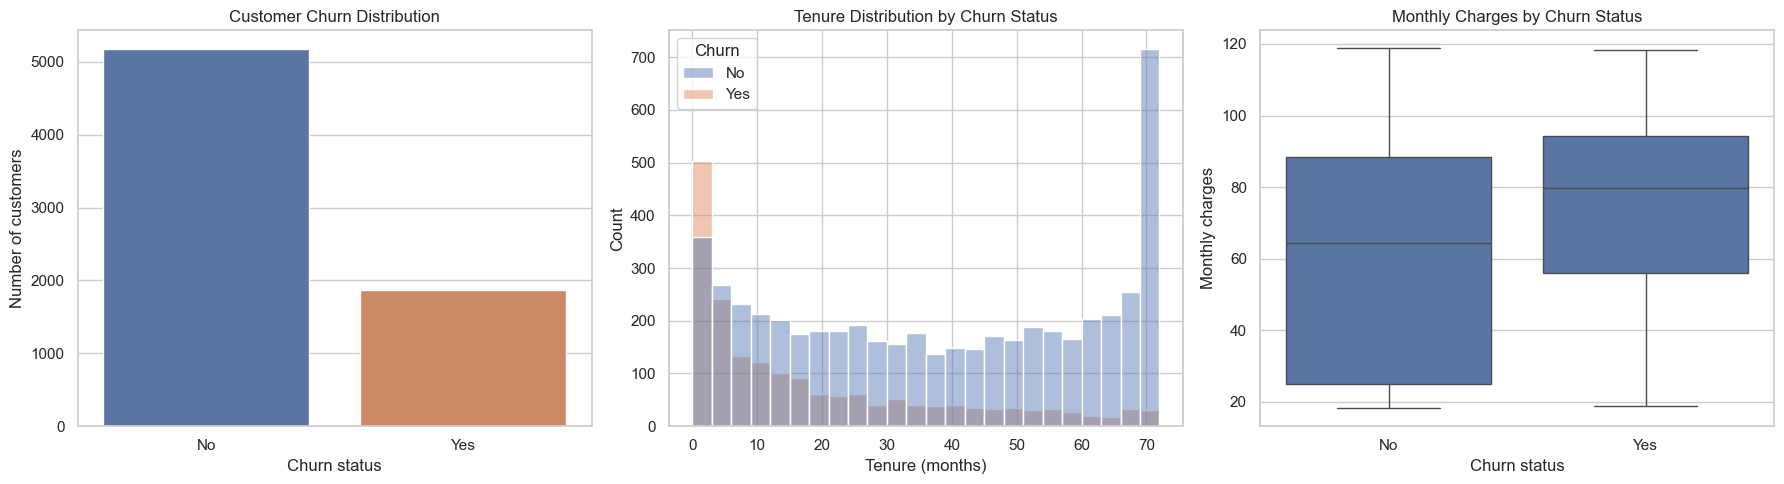

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Customer churn count
sns.countplot(data=df_clean, x="Churn", hue="Churn", legend=False, ax=axes[0])
axes[0].set_title("Customer Churn Distribution")
axes[0].set_xlabel("Churn status")
axes[0].set_ylabel("Number of customers")

# 2. Tenure distribution by churn
sns.histplot(
    data=df_clean,
    x="tenure",
    hue="Churn",
    bins=24,
    multiple="layer",
    alpha=0.45,
    ax=axes[1]
)
axes[1].set_title("Tenure Distribution by Churn Status")
axes[1].set_xlabel("Tenure (months)")

# 3. Monthly charges distribution by churn
sns.boxplot(data=df_clean, x="Churn", y="MonthlyCharges", ax=axes[2])
axes[2].set_title("Monthly Charges by Churn Status")
axes[2].set_xlabel("Churn status")
axes[2].set_ylabel("Monthly charges")

plt.tight_layout()
plt.show()

In [35]:
contract_churn = (
    df_clean.groupby("Contract", observed=True)
    .agg(
        customers=("customerID", "count"),
        churn_rate=("ChurnFlag", "mean"),
        average_monthly_charges=("MonthlyCharges", "mean"),
        median_tenure=("tenure", "median")
    )
    .sort_values("churn_rate", ascending=False)
)

contract_churn["churn_rate"] = contract_churn["churn_rate"].map("{:.2%}".format)
contract_churn["average_monthly_charges"] = (
    contract_churn["average_monthly_charges"].map("${:.2f}".format)
)

contract_churn

,customers,churn_rate,average_monthly_charges,median_tenure
Contract,,,,
Month-to-month,3875,42.71%,$66.40,12.0
One year,1473,11.27%,$65.05,44.0
Two year,1695,2.83%,$60.77,64.0


In [36]:
def show_churn_rate_by_category(data, column):
    summary = (
        data.groupby(column, observed=True)
        .agg(
            customers=("customerID", "count"),
            churn_rate=("ChurnFlag", "mean")
        )
        .sort_values("churn_rate", ascending=False)
    )

    display(summary.assign(
        churn_rate=summary["churn_rate"].map("{:.2%}".format)
    ))

    plot_data = summary.reset_index()
    sns.barplot(data=plot_data, x=column, y="churn_rate", color="#6C5CE7")
    plt.title(f"Observed Churn Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Churn rate")
    plt.ylim(0, max(plot_data["churn_rate"]) * 1.15)
    plt.xticks(rotation=25, ha="right")
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.tight_layout()
    plt.show()

,customers,churn_rate
Contract,,
Month-to-month,3875,42.71%
One year,1473,11.27%
Two year,1695,2.83%


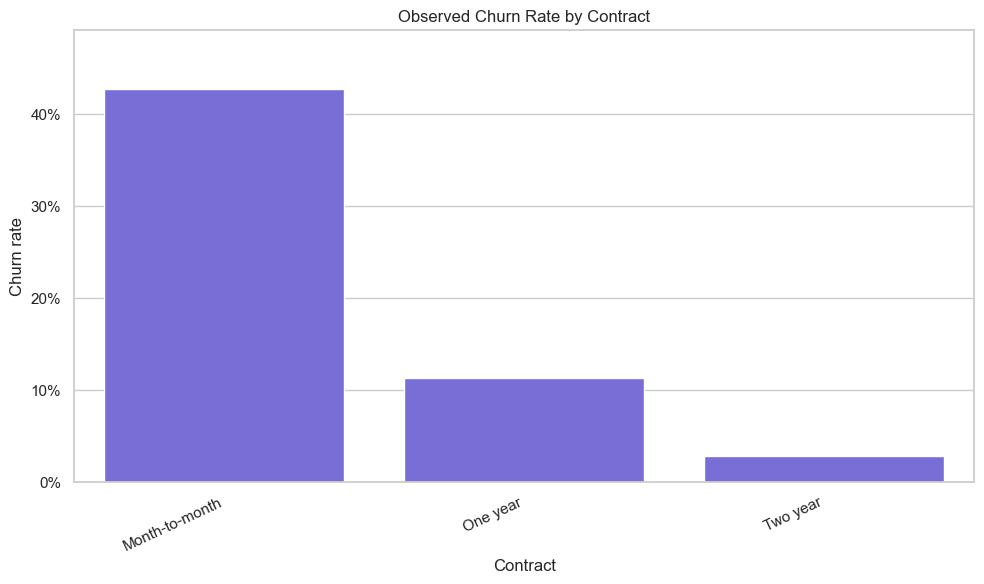

,customers,churn_rate
InternetService,,
Fiber optic,3096,41.89%
DSL,2421,18.96%
No,1526,7.40%


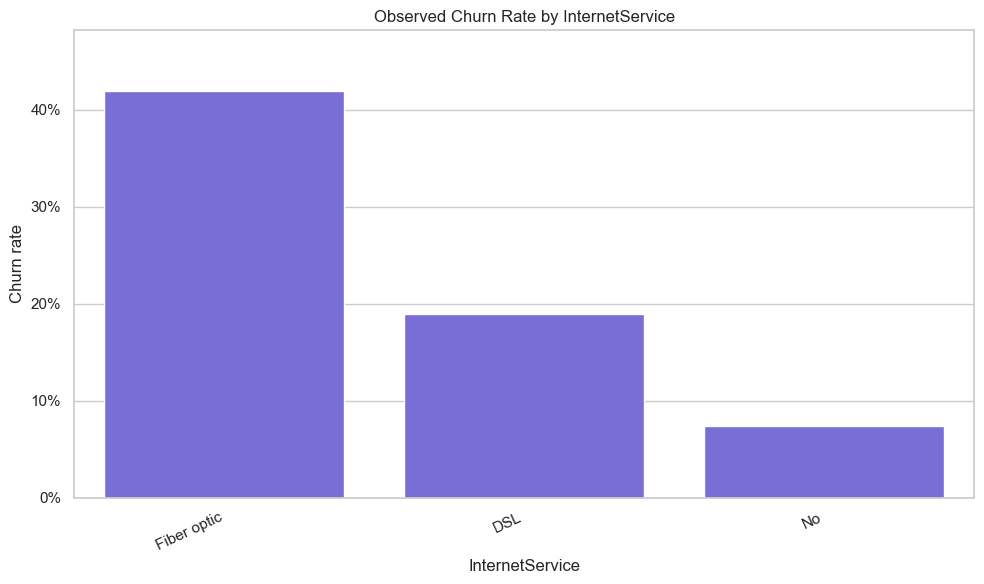

,customers,churn_rate
PaymentMethod,,
Electronic check,2365,45.29%
Mailed check,1612,19.11%
Bank transfer (automatic),1544,16.71%
Credit card (automatic),1522,15.24%


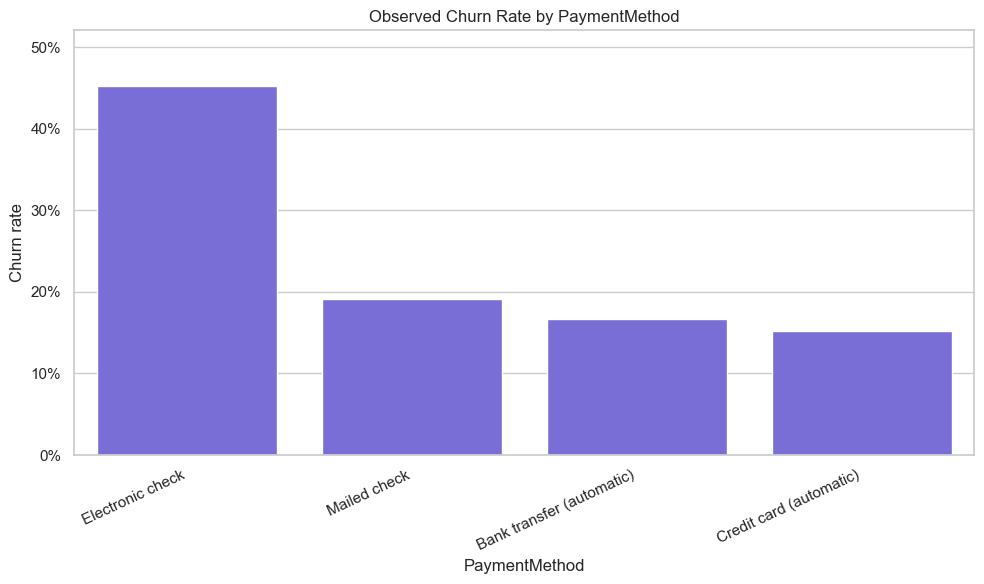

,customers,churn_rate
TechSupport,,
No,3473,41.64%
Yes,2044,15.17%
No internet service,1526,7.40%


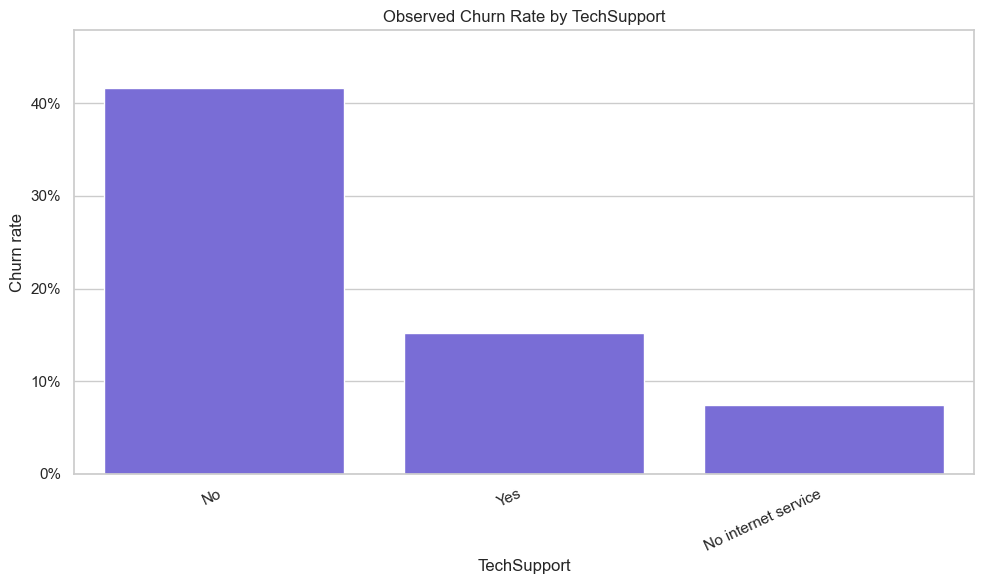

In [37]:
for column in ["Contract", "InternetService", "PaymentMethod", "TechSupport"]:
    show_churn_rate_by_category(df_clean, column)

## Key EDA findings

- Overall churn is 26.5% (1,869 of 7,043 customers).
- Month-to-month customers have the highest observed churn rate (42.71%), compared with one-year (11.27%) and two-year contracts (2.83%).
- Fiber-optic customers have a 41.89% observed churn rate, versus 18.96% for DSL customers and 7.40% for customers without internet service.
- Customers using electronic checks have the highest observed churn rate (45.29%). The three other payment methods range from 15.24% to 19.11%.
- Customers without tech support show a 41.64% observed churn rate, compared with 15.17% among customers with tech support.
- The charts also show that churn is more concentrated among shorter-tenure customers, while churned customers tend to have higher monthly charges.

These are associations in this benchmark dataset, not proof that a feature causes churn.